In [4]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from data_preprocessing import preprocess

In [6]:
filepath = "/Users/saumyamishra/Desktop/Ashoka/sem 5/Introduction to Machine Learning/Saumya_Mishra_A1/decision_tree_task/data/train_data.csv"
dataset = pd.read_csv(filepath, usecols=lambda x: x not in ["isFlaggedFraud"])
dataset.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,686,CASH_OUT,1467968.73,C1032013375,1467968.73,0.00,C293921513,0.00,1467968.73,1
1,210,CASH_OUT,113615.25,C1933223662,7905.00,0.00,C657984082,597940.50,711555.75,0
2,308,CASH_IN,57180.32,C483203297,2249932.73,2307113.05,C1835281457,206526.46,149346.14,0
3,34,CASH_IN,222389.38,C703351260,6846615.66,7069005.04,C163255774,449960.13,227570.75,0
4,276,CASH_OUT,41845.14,C1597072697,0.00,0.00,C421084235,3341767.77,3383612.91,0


In [7]:
#statistics about dataset
dataset.info()

#duplicates
dataset.duplicated().sum()

#missing data
dataset.isnull().sum()

dataset['step'].value_counts()

dataset['isFraud'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170723 entries, 0 to 170722
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            170723 non-null  int64  
 1   type            170723 non-null  object 
 2   amount          170723 non-null  float64
 3   nameOrig        170723 non-null  object 
 4   oldbalanceOrg   170723 non-null  float64
 5   newbalanceOrig  170723 non-null  float64
 6   nameDest        170723 non-null  object 
 7   oldbalanceDest  170723 non-null  float64
 8   newbalanceDest  170723 non-null  float64
 9   isFraud         170723 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 13.0+ MB


isFraud
0    165238
1      5485
Name: count, dtype: int64

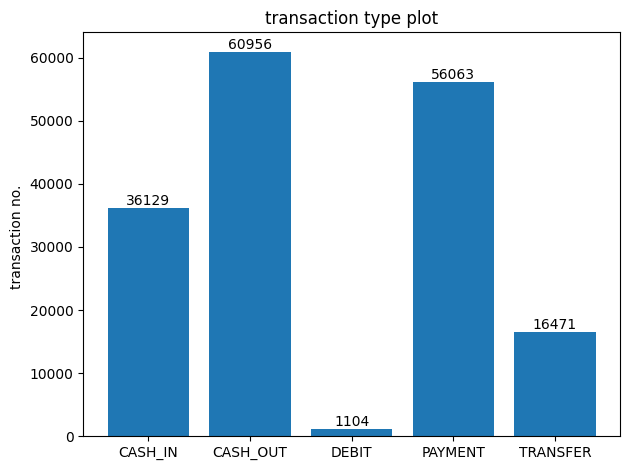

In [8]:
types, counts = np.unique(dataset['type'], return_counts=True)

fig, ax = plt.subplots()
bars = ax.bar(types, counts)

ax.bar_label(bars)

ax.set_title('transaction type plot')
ax.set_ylabel('transaction no. ')

ax.set_xticks(range(len(types)))
ax.set_xticklabels(types)

plt.tight_layout()

plt.show()

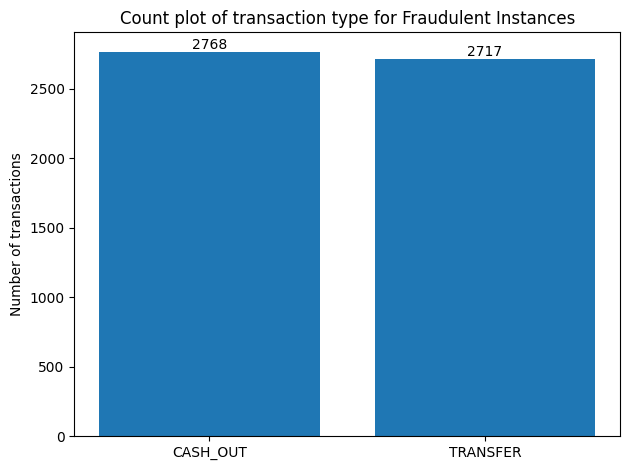

In [9]:
fraud_data = dataset[dataset['isFraud'] == 1]

types, counts = np.unique(fraud_data['type'], return_counts=True)
fig, ax = plt.subplots()
bars = ax.bar(types, counts)
ax.bar_label(bars)
ax.set_title('Count plot of transaction type for Fraudulent Instances')
ax.set_ylabel('Number of transactions')
ax.set_xticks(range(len(types)))
ax.set_xticklabels(types)
plt.tight_layout()
plt.show()

dataset['fraud_type'] = dataset['type'].apply(lambda x: 1 if x in ['CASH_OUT', 'TRANSFER'] else 0)

since fraud only happens in cash_out or transfer, we will make a column that marks one if it is either of these, and 0 otherwise, and will drop type.

In [10]:
dataset['fraud_type'] = dataset['type'].apply(lambda x: 1 if x in ['CASH_OUT', 'TRANSFER'] else 0)

In [11]:
fraud_data.sample(30)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
82515,38,TRANSFER,3372.00,C2049498532,3372.00,0.0,C1540407960,0.00,0.00,1
23535,187,CASH_OUT,7196174.56,C1906024708,7196174.56,0.0,C252431988,14743.59,7094510.52,1
8009,336,CASH_OUT,9207.38,C202544710,9207.38,0.0,C728550781,0.00,9207.38,1
12437,400,TRANSFER,51113.00,C109032105,51113.00,0.0,C1072918822,0.00,0.00,1
156309,11,CASH_OUT,12461.00,C938980312,12461.00,0.0,C621014131,27964.11,40425.11,1
121098,98,CASH_OUT,63624.08,C431038121,63624.08,0.0,C1925188324,0.00,63624.08,1
31894,250,TRANSFER,177217.55,C1034306839,177217.55,0.0,C1979293202,0.00,0.00,1
55787,527,CASH_OUT,6087.58,C645627086,6087.58,0.0,C616112992,3584904.50,3590992.07,1
7838,379,TRANSFER,4445514.20,C1149729385,4445514.20,0.0,C246500623,0.00,0.00,1
112879,9,TRANSFER,556218.01,C1769581889,556218.01,0.0,C217441120,0.00,0.00,1


In [12]:
dataset['full_withdraw'] = dataset.apply(lambda row: 1 if row['amount'] == row['oldbalanceOrg'] else 0, axis=1)


In [13]:
rows1 = len(dataset[(dataset['full_withdraw'] == 0) & (dataset['isFraud'] == 1)])
print('Number of frauds that are not full withdrawals:')
print(rows1)

rows2 = len(dataset[(dataset['full_withdraw'] == 1) & (dataset['isFraud'] == 0)])
print('Full withdrawals that are not frauds:')
print(rows2)

Number of frauds that are not full withdrawals:
127
Full withdrawals that are not frauds:
0


clearly, amount == oldBalanceOrg is a necessary (but not sufficient) criterion to say that a transaction is fradulent. so, we will make a column marking a 1 if they are equal, and 0 otherwise.

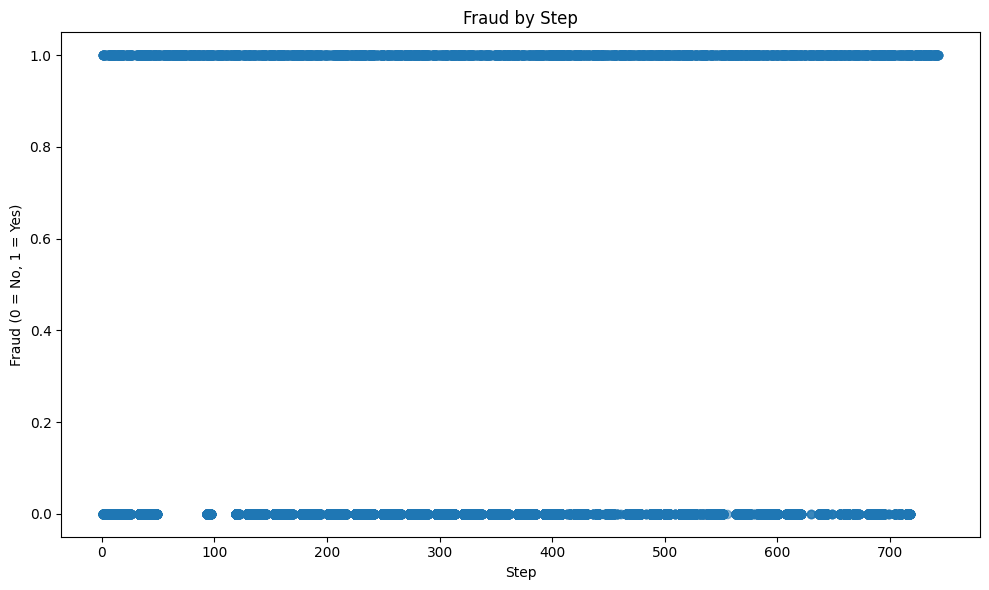

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(dataset['step'], dataset['isFraud'], alpha=0.5)

plt.title('Fraud by Step')
plt.xlabel('Step')
plt.ylabel('Fraud (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()


there appears to be a gap between 55 and 110 where there is only fraud taking place. we will add another column for points that are in this range, as follows:

In [15]:
dataset['suspcisious_time_frame'] = dataset['step'].apply(lambda x: 10 if 55 <= x <= 110 else 5)
dataset.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,fraud_type,full_withdraw,suspcisious_time_frame
0,686,CASH_OUT,1467968.73,C1032013375,1467968.73,0.00,C293921513,0.00,1467968.73,1,1,1,5
1,210,CASH_OUT,113615.25,C1933223662,7905.00,0.00,C657984082,597940.50,711555.75,0,1,0,5
2,308,CASH_IN,57180.32,C483203297,2249932.73,2307113.05,C1835281457,206526.46,149346.14,0,0,0,5
3,34,CASH_IN,222389.38,C703351260,6846615.66,7069005.04,C163255774,449960.13,227570.75,0,0,0,5
4,276,CASH_OUT,41845.14,C1597072697,0.00,0.00,C421084235,3341767.77,3383612.91,0,1,0,5


In [16]:
dataset.drop(columns=['type'], inplace=True)


In [18]:
dataset.drop(columns=['nameOrig', 'nameDest'], inplace=True)

KeyError: "['nameOrig', 'nameDest'] not found in axis"

In [19]:
dataset.drop(columns=['newbalanceDest', 'oldbalanceDest', 'step'], inplace=True)

In [20]:
dataset.drop(columns=['newbalanceOrig', 'oldbalanceOrg', 'amount'], inplace=True)
dataset.head()

,isFraud,fraud_type,full_withdraw,suspcisious_time_frame
0,1,1,1,5
1,0,1,0,5
2,0,0,0,5
3,0,0,0,5
4,0,1,0,5


MODEL TESTING BELOW
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


In [21]:
filepath = "/Users/saumyamishra/Desktop/Ashoka/sem 5/Introduction to Machine Learning/Saumya_Mishra_A1/decision_tree_task/data/train_data.csv"

class Node():
    """
    node class
    """

    def __init__(self, feature=None, threshold=None, left=None, right=None, gain=None, value=None):

        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.gain = gain
        self.value = value

class DecisionTree():


    def __init__(self, min_samples=2, max_depth=4):

        self.min_samples = min_samples
        self.max_depth = max_depth

    def data_split(self, dataset, feature, threshold):

        # Create empty arrays to store the left and right datasets
        left_dataset = []
        right_dataset = []
        
        # Loop over each row in the dataset and split based on the given feature and threshold
        for row in dataset:
            if row[feature] <= threshold:
                left_dataset.append(row)
            else:
                right_dataset.append(row)

        # Convert the left and right datasets to numpy arrays and return
        left_dataset = np.array(left_dataset)
        right_dataset = np.array(right_dataset)
        return left_dataset, right_dataset

    def entropy(self, y):

        entropy = 0

        # Find the unique label values in y and loop over each value
        labels = np.unique(y)
        for label in labels:
            # Find the examples in y that have the current label
            label_examples = y[y == label]
            # Calculate the ratio of the current label in y
            pl = len(label_examples) / len(y)
            # Calculate the entropy using the current label and ratio
            entropy += -pl * np.log2(pl)

        # Return the final entropy value
        return entropy

    def information_gain(self, parent, left, right):

        # Set initial information gain to 0
        information_gain = 0
        # Compute entropy for the parent dataset
        parent_entropy = self.entropy(parent)
        # Calculate weight for left and right nodes
        weight_left = len(left) / len(parent)
        weight_right= len(right) / len(parent)
        # Compute entropy for left and right nodes
        entropy_left, entropy_right = self.entropy(left), self.entropy(right)
        # Calculate weighted entropy 
        weighted_entropy = weight_left * entropy_left + weight_right * entropy_right
        # Calculate information gain 
        information_gain = parent_entropy - weighted_entropy
        return information_gain

    
    def best_split(self, dataset, num_samples, num_features):
     
        # Dictionary to store the best split values
        best_split = {'gain': -1, 'feature': None, 'threshold': None}
        # Loop over all features
        for feature_index in range(num_features):
            # Get the values of the current feature
            feature_values = dataset[:, feature_index]
            # Get unique values of that feature
            thresholds = np.unique(feature_values)
            # Loop over all unique values of the feature
            for threshold in thresholds:
                # Get left and right datasets based on the threshold
                left_dataset, right_dataset = self.data_split(dataset, feature_index, threshold)
                # Check if either dataset is empty
                if len(left_dataset) and len(right_dataset):
                    # Get label values for parent and child nodes
                    y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]
                    # Compute information gain based on the label values
                    information_gain = self.information_gain(y, left_y, right_y)
                    # Update the best split if this gain is higher
                    if information_gain > best_split["gain"]:
                        best_split["feature"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["left_dataset"] = left_dataset
                        best_split["right_dataset"] = right_dataset
                        best_split["gain"] = information_gain
        return best_split

    
    def calculate_leaf_value(self, y):

        y = list(y)
        # Get the highest present class in the array
        most_occuring_value = max(y, key=y.count)
        return most_occuring_value
    
    def build_tree(self, dataset, current_depth=0):

        # Split the dataset into features (X) and labels (y)
        X, y = dataset[:, :-1], dataset[:, -1]
        n_samples, n_features = X.shape
        # Continue splitting until stopping conditions are met
        if n_samples >= self.min_samples and current_depth <= self.max_depth:
            # Get the best split based on the dataset
            best_split = self.best_split(dataset, n_samples, n_features)
            # Check if gain is not zero
            if best_split["gain"]:
                # Recursively build the left and right child nodes, incrementing depth
                left_node = self.build_tree(best_split["left_dataset"], current_depth + 1)
                right_node = self.build_tree(best_split["right_dataset"], current_depth + 1)
                # Return the decision node
                return Node(best_split["feature"], best_split["threshold"],
                            left_node, right_node, best_split["gain"])

        # Compute the value for the leaf node
        leaf_value = self.calculate_leaf_value(y)
        # Return the leaf node with the computed value
        return Node(value=leaf_value)
    
    def fit(self, X, y):
  
        dataset = np.concatenate((X, y), axis=1)  
        self.root = self.build_tree(dataset)

    def predict(self, X):

        #  empty list to store the predictions
        predictions = []
        # For each instance in X, make a prediction by traversing the tree
        for x in X:
            prediction = self.make_prediction(x, self.root)
            # Append the prediction to the list of predictions
            predictions.append(prediction)
        # Convert the list to a numpy array and return it
        np.array(predictions)
        return predictions
    
    def make_prediction(self, x, node):
   
        # If the node has a value (leaf node), extract its value
        if node.value is not None: 
            return node.value
        else:
            # If it's not a leaf node, traverse according to the feature value
            feature = x[node.feature]
            if feature <= node.threshold:
                return self.make_prediction(x, node.left)
            else:
                return self.make_prediction(x, node.right)
            
import numpy as np

# Function to calculate the confusion matrix using numpy
def confusion_matrix_np(y_true, y_pred):

    TN = np.sum((y_pred == 0) & (y_true == 0))  # True Negatives
    FP = np.sum((y_pred == 1) & (y_true == 0))  # False Positives
    FN = np.sum((y_pred == 0) & (y_true == 1))  # False Negatives
    TP = np.sum((y_pred == 1) & (y_true == 1))  # True Positives
    return np.array([[TN, FP], [FN, TP]])


def accuracy_score_np(y_true, y_pred):

    return np.mean(y_true == y_pred)


def precision_score_np(y_true, y_pred):

    TP = np.sum((y_pred == 1) & (y_true == 1))  # True Positives
    FP = np.sum((y_pred == 1) & (y_true == 0))  # False Positives
    return TP / (TP + FP) if (TP + FP) > 0 else 0  # Avoid division by zero


def recall_score_np(y_true, y_pred):

    TP = np.sum((y_pred == 1) & (y_true == 1))  # True Positives
    FN = np.sum((y_pred == 0) & (y_true == 1))  # False Negatives
    return TP / (TP + FN) if (TP + FN) > 0 else 0  # Avoid division by zero


def f1_score_np(y_true, y_pred):

    precision = precision_score_np(y_true, y_pred)
    recall = recall_score_np(y_true, y_pred)
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


def calculate_metrics(y_true, y_pred):
    
    conf_matrix = confusion_matrix_np(y_true, y_pred)
    accuracy = accuracy_score_np(y_true, y_pred)
    precision = precision_score_np(y_true, y_pred)
    recall = recall_score_np(y_true, y_pred)
    f1 = f1_score_np(y_true, y_pred)
    
    return accuracy, precision, recall, f1, conf_matrix

            
def train_test_split(X, y, random_state=41, test_size=0.2):

    n_samples = X.shape[0]

    np.random.seed(random_state)

    shuffled_indices = np.random.permutation(np.arange(n_samples))

    test_size = int(n_samples * test_size)

    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size:]

    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

def accuracy(y_true, y_pred):

    y_true = y_true.flatten()
    total_samples = len(y_true)
    correct_predictions = np.sum(y_true == y_pred)
    return (correct_predictions / total_samples) 

dataset = preprocess(filepath)

def undersample(df, target_column, ratio=1):
    # Identify the minority and majority classes
    class_counts = df[target_column].value_counts()
    minority_class = class_counts.idxmin()
    majority_class = class_counts.idxmax()
    
    # Separate the minority and majority classes
    df_minority = df[df[target_column] == minority_class]
    df_majority = df[df[target_column] == majority_class]
    
    # Determine the number of majority samples to keep (based on the 1:5 ratio)
    majority_sample_size = len(df_minority) * ratio
    
    # Randomly undersample the majority class to achieve the 1:5 ratio
    df_majority_undersampled = df_majority.sample(majority_sample_size, random_state=42)
    
    # Combine the undersampled majority class with the minority class
    df_undersampled = pd.concat([df_minority, df_majority_undersampled])
    
    # Shuffle the resulting DataFrame
    df_undersampled = df_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return df_undersampled

NameError: name 'preprocess' is not defined

In [127]:
filepath = "/Users/saumyamishra/Desktop/Ashoka/sem 5/Introduction to Machine Learning/Saumya_Mishra_A1/decision_tree_task/data/fraud_train.csv"
dataset = pd.read_csv(filepath, usecols=lambda x: x not in ["isFlaggedFraud"])
dataset = preprocess(dataset)
dataset.head()

,isFraud,fraud_type,full_withdraw,suspcisious_time_frame
0,0,0,0,5
1,0,0,0,5
2,0,0,0,5
3,0,1,0,5
4,0,1,0,5


In [ ]:
# 'fraud_type' column based on transaction type
dataset['fraud_type'] = dataset['type'].apply(lambda x: 1 if x in ['CASH_OUT', 'TRANSFER'] else 0)

# 'full_withdraw' column based on whether amount == oldbalanceOrg
dataset['full_withdraw'] = dataset.apply(lambda row: 1 if row['amount'] == row['oldbalanceOrg'] else 0, axis=1)

# 'suspicious_time_frame' column
dataset['suspcisious_time_frame'] = dataset['step'].apply(lambda x: 10 if 55 <= x <= 110 else 5)

# drop unwanted columns
dataset.drop(columns=['type', 'nameOrig', 'nameDest', 'newbalanceDest', 'oldbalanceDest', 'step', 
                        'newbalanceOrig', 'oldbalanceOrg', 'amount'], inplace=True)

In [18]:
def accuracy(y_true, y_pred):
    """
    Computes the accuracy of a classification model.

    Parameters:
    ----------
        y_true (numpy array): A numpy array of true labels for each data point.
        y_pred (numpy array): A numpy array of predicted labels for each data point.

    Returns:
    ----------
        float: The accuracy of the model
    """
    y_true = y_true.flatten()
    total_samples = len(y_true)
    correct_predictions = np.sum(y_true == y_pred)
    return (correct_predictions / total_samples) 

In [103]:
def balanced_accuracy(y_true, y_pred):
    """Calculate the balanced accuracy for a multi-class classification problem.

    Parameters
    ----------
        y_true (numpy array): A numpy array of true labels for each data point.
        y_pred (numpy array): A numpy array of predicted labels for each data point.

    Returns
    -------
        balanced_acc : The balanced accuracy of the model
        TP: List of true positives for each class
        TN: List of true negatives for each class
        FP: List of false positives for each class
        FN: List of false negatives for each class
        
    """
    y_pred = np.array(y_pred)
    y_true = y_true.flatten()
    # Get the number of classes
    n_classes = len(np.unique(y_true))

    # Initialize arrays to store TP, TN, FP, FN for each class
    TP = []
    TN = []
    FP = []
    FN = []

    # Initialize arrays to store sensitivity and specificity for each class
    sen = []
    spec = []

    # Loop over each class
    for i in range(n_classes):
        # Create a mask for the true and predicted values for class i
        mask_true = y_true == i
        mask_pred = y_pred == i

        # Calculate TP, TN, FP, FN
        TP_i = np.sum(mask_true & mask_pred)
        TN_i = np.sum((mask_true == False) & (mask_pred == False))
        FP_i = np.sum((mask_true == False) & mask_pred)
        FN_i = np.sum(mask_true & (mask_pred == False))

        # Store TP, TN, FP, FN for class i
        TP.append(TP_i)
        TN.append(TN_i)
        FP.append(FP_i)
        FN.append(FN_i)

        # Calculate sensitivity (true positive rate) and specificity (true negative rate)
        sensitivity = TP_i / (TP_i + FN_i) if (TP_i + FN_i) > 0 else 0
        specificity = TN_i / (TN_i + FP_i) if (TN_i + FP_i) > 0 else 0

        # Store sensitivity and specificity for class i
        sen.append(sensitivity)
        spec.append(specificity)

    # Calculate the balanced accuracy as the average of the sensitivity and specificity for each class
    average_sen = np.mean(sen)
    average_spec = np.mean(spec)
    balanced_acc = (average_sen + average_spec) / n_classes

    return balanced_acc, TP, TN, FP, FN

In [111]:
def undersample(df, target_column, ratio=1):
    # Identify the minority and majority classes
    class_counts = df[target_column].value_counts()
    minority_class = class_counts.idxmin()
    majority_class = class_counts.idxmax()
    
    # Separate the minority and majority classes
    df_minority = df[df[target_column] == minority_class]
    df_majority = df[df[target_column] == majority_class]
    
    # Determine the number of majority samples to keep (based on the 1:5 ratio)
    majority_sample_size = len(df_minority) * ratio
    
    # Randomly undersample the majority class to achieve the 1:5 ratio
    df_majority_undersampled = df_majority.sample(majority_sample_size, random_state=42)
    
    # Combine the undersampled majority class with the minority class
    df_undersampled = pd.concat([df_minority, df_majority_undersampled])
    
    # Shuffle the resulting DataFrame
    df_undersampled = df_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return df_undersampled

# Example usage
# Assuming your target column is named 'target'
undersampled_df = undersample(dataset, target_column='isFraud', ratio=5)

undersampled_df.head()


,isFraud,fraud_type,full_withdraw,suspcisious_time_frame
0,0,1,0,5
1,0,0,0,5
2,0,0,0,5
3,1,1,1,5
4,0,0,0,5


In [112]:
y = undersampled_df.pop('isFraud')
undersampled_df.shape[0]

39558

In [113]:
y.head()

0    0
1    0
2    0
3    1
4    0
Name: isFraud, dtype: int64

In [116]:
X = undersampled_df.copy()

shuffled_indices = np.random.permutation(len(X))
test_size = int(len(X) * 0.2)
test_indices = shuffled_indices[:test_size]
train_indices = shuffled_indices[test_size:]

X_train, X_test = X.iloc[train_indices].to_numpy(), X.iloc[test_indices].to_numpy()
y_train, y_test = y.iloc[train_indices].to_numpy().reshape(-1,1), y.iloc[test_indices].to_numpy().reshape(-1,1)



In [117]:
print(y_train.shape)

(31647, 1)


In [118]:
#create model instance
model = DecisionTree(2, 2)

# Fit the decision tree model to the training data.
model.fit(X_train, y_train)

# Use the trained model to make predictions on the test data.
predictions = model.predict(X_test)

# Calculate evaluating metrics
print(f"Model's Accuracy: {accuracy(y_test, predictions)}")
print(f"Model's Balanced Accuracy: {balanced_accuracy(y_test, predictions)}")

Model's Accuracy: 0.9953229680192137
Model's Balanced Accuracy: (0.9858993902439024, [6599, 1275], [1275, 6599], [37, 0], [0, 37])


In [119]:
# Calculate evaluating metrics
print(f"Model's Accuracy: {accuracy(y_test, predictions)}")
      
balanced_acc, TP, TN, FP, FN  = balanced_accuracy(y_test, predictions)

Model's Accuracy: 0.9953229680192137


In [108]:
def compute_confusion_matrix(TP, TN, FP, FN):
    """Construct confusion matrix using TP, TN, FP, FN."""
    n_classes = len(TP)
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=int)

    # Fill the confusion matrix
    for i in range(n_classes):
        confusion_matrix[i, i] = TP[i]  # True Positives for each class
        for j in range(n_classes):
            if i != j:
                confusion_matrix[i, j] = FP[j] if i == 1 else FN[i]  # False Positives and False Negatives

    return confusion_matrix

def plot_confusion_matrix(confusion_matrix, classes):
    """Plot the confusion matrix."""
    df_cm = pd.DataFrame(confusion_matrix, index=classes, columns=classes)

    plt.figure(figsize=(8, 6))
    plt.imshow(df_cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by row (i.e. by the number of samples)
    normalized_cm = confusion_matrix.astype('float') / confusion_matrix.sum(axis=1)[:, np.newaxis]
    
    # Print the confusion matrix values in the matrix
    thresh = normalized_cm.max() / 2.
    for i, j in np.ndindex(normalized_cm.shape):
        plt.text(j, i, f"{normalized_cm[i, j]:.2f}", horizontalalignment="center", 
                 color="white" if normalized_cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

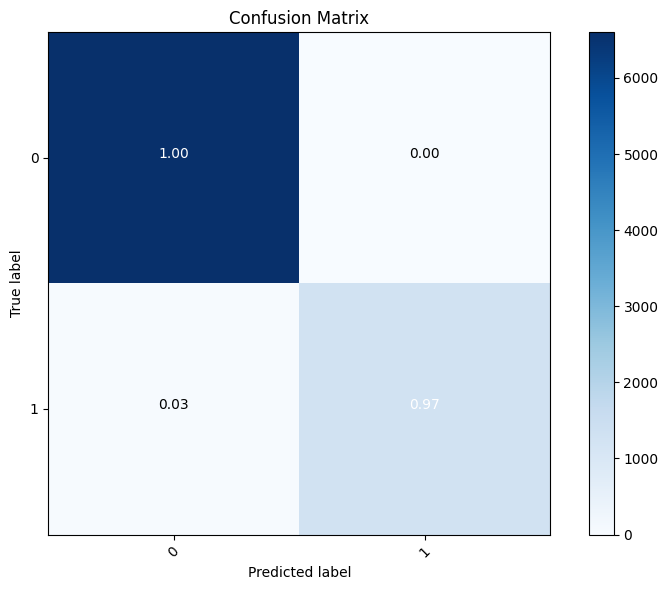

In [120]:
confusion_matrix = compute_confusion_matrix(TP, TN, FP, FN)
    
y_true = np.array([0, 1, 0, 0, 1, 1, 1, 0])

# Define class labels
classes = np.unique(y_true)

# Plot confusion matrix
plot_confusion_matrix(confusion_matrix, classes)

In [121]:
print(confusion_matrix)

[[6599    0]
 [  37 1275]]


In [101]:
import pickle

In [122]:
model_filename = 'model2.pkl'

# Open a file in write-binary mode and pickle the model
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved to {model_filename}")


Model saved to model2.pkl


In [128]:
def load_model(model_path):
    """
    Loads a saved model from the specified file path.
    
    Args:
        model_path (str): Path to the saved model.
        
    Returns:
        model: Loaded model object.
    """
    with open(model_path, 'rb') as model_file:
        model = pickle.load(model_file)
    return model

In [130]:
filepath2 = '/Users/saumyamishra/Desktop/Ashoka/sem 5/Introduction to Machine Learning/Saumya_Mishra_A1/decision_tree_task/models/model2.pkl'
model = load_model(filepath2)



In [131]:
predictions = model.predict(X_test)

# Calculate evaluating metrics
print(f"Model's Accuracy: {accuracy(y_test, predictions)}")
print(f"Model's Balanced Accuracy: {balanced_accuracy(y_test, predictions)}")

Model's Accuracy: 0.9953229680192137
Model's Balanced Accuracy: (0.9858993902439024, [6599, 1275], [1275, 6599], [37, 0], [0, 37])
